# Teaching Computers to See: Building an Image Classifier with CNNs

**Course:** AI and Machine Learning for IT Engineers (ST2AIM) — 2026-2027
**Instructors:** Ahmad TAY, Faten CHAIEB, Hamza KCHOK, Asma GABIS
**Student:** Victor Haegeman

---


In [1]:
# Standard scientific stack
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report)

# Reproducibility & display settings
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# Project settings
BASE_DIR   = "cats_and_dogs_filtered"
IMG_SIZE   = (150, 150)     # every image is resized to this fixed shape
BATCH_SIZE = 100            # batch size required by the assignment
EPOCHS     = 15             # within the 5-15 range required by the assignment

print("TensorFlow:", tf.__version__)

I0000 00:00:1789398433.444653     818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789398433.491359     818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789398435.463917     818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


---
## Part 1 — Introduction to CNNs

### 1.1 — What are CNNs and how do they work?

A CNN is a neural network built for images. Instead of looking at the whole picture at once, it slides
a small window across it and looks for one simple pattern at a time — a vertical edge, a patch of
texture. It does that many times over, and the patterns it finds get combined into bigger ones, until
the last layer can answer "cat" or "dog".

The main difference with a regular network is an image is very big once you flatten it. Our images are
150 × 150 pixels in colour, which is 150 × 150 × 3 = **67,500 numbers**. If we take a single
ordinary layer of 1,000 neurons, you already have 67.5 million values to learn. On top of that, flattening
scrambles the picture: the network no longer knows which pixel was next to which, and a shape it
learns in the top-left corner has to be learned again for every other position.

A CNN avoids all three problems with two structural properties:

- **Local connectivity** — a neuron is connected only to a small window of the input (3 × 3 here), and so not the whole image.

- **Weight sharing** — the same kernel is slid over every position, so a pattern learned at
  one location can be detected everywhere, and the parameter count becomes independent of the image size.

Stacking such layers builds a hierarchy of features: edges → textures → object parts → objects. The
network is trained end-to-end by backpropagation, so the kernel coefficients are learned, not designed.


### 1.2 — Key components

| Component | Operation | Learnable parameters | Output size |
|---|---|---|---|
| `Conv2D` | Slides $M$ kernels of size $K \times K \times C_{in}$ over the input; each kernel outputs one feature map: $z = \sum_i \sum_j X_{ij} K_{ij} + b$ | $M(K \times K \times C_{in} + 1)$ | $\left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$, depth $M$ |
| Activation (`ReLU`) | $\text{ReLU}(z) = \max(0, z)$, applied element-wise | none | unchanged |
| `MaxPooling2D` | Keeps the maximum value of each $K \times K$ window | none | $\left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1$, depth unchanged |
| `Flatten` + `Dense` | Flattens the final feature volume into a vector and applies a fully connected classifier | $n_{in} \times n_{out} + n_{out}$ | $n_{out}$ |

There would be two main points:

1. **Convolution is a linear operation.** Without a non-linear activation, stacking convolutional layers
   would collapse into a single linear map. ReLU provides that non-linearity at almost no computational
   cost and does not saturate for positive inputs, which limits vanishing gradients.
   
2. **Pooling has no weights.** It reduces the spatial resolution — which cuts computation and memory,
   enlarges the receptive field of the following layers, and grants a small invariance to translation —
   but it is a fixed operation, not a learned one.

---
## Part 2 — Dataset Exploration

### 2.1 — Load the dataset

The images sit in two folders, `cats/` and `dogs/`, so the folder name gives the label.
`image_dataset_from_directory` reads that directly: it labels the images, resizes them to
150 × 150, and batches them. `label_mode="binary"` gives labels 0 and 1.

It was suggested `ImageDataGenerator`. I used `image_dataset_from_directory` instead which is recommended in tenserflow.

In [2]:
train_dir = os.path.join(BASE_DIR, "train")
val_dir   = os.path.join(BASE_DIR, "validation")

n_train_cats = len(os.listdir(os.path.join(train_dir, "cats")))
n_train_dogs = len(os.listdir(os.path.join(train_dir, "dogs")))
n_val_cats   = len(os.listdir(os.path.join(val_dir,   "cats")))
n_val_dogs   = len(os.listdir(os.path.join(val_dir,   "dogs")))

counts = pd.DataFrame(
    {"cats": [n_train_cats, n_val_cats], "dogs": [n_train_dogs, n_val_dogs]},
    index=["train directory", "validation directory"])
counts["total"] = counts.sum(axis=1)
counts["share of cats"] = (counts["cats"] / counts["total"]).round(3)
counts

,cats,dogs,total,share of cats
train directory,1000,1000,2000,0.5
validation directory,500,500,1000,0.5


### 2.2 — How many cat and dog images are there in the training and validation directories?

The `train` directory holds **1,000 cats and 1,000 dogs** (2,000 images), the `validation` directory
**500 cats and 500 dogs** (1,000 images), for a total of 3,000 images.

### 2.3 — Class distribution and input shape

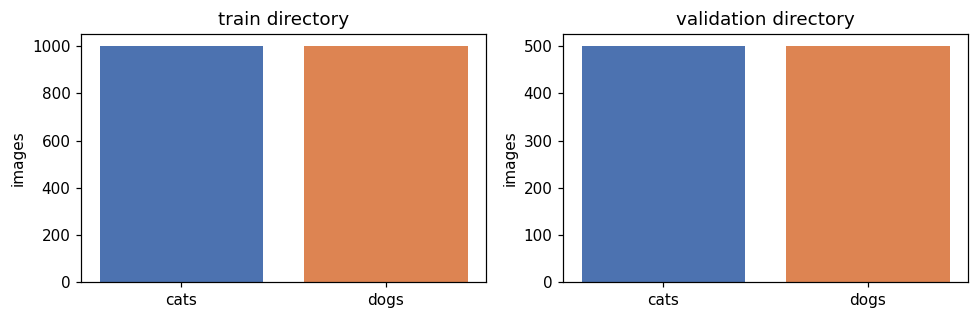

             height  width  channels
cat.0.jpg       374    500         3
cat.1.jpg       280    300         3
cat.10.jpg      499    489         3
cat.100.jpg     499    403         3
cat.101.jpg     200    296         3


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for a, (name, row) in zip(ax, counts.iterrows()):
    a.bar(["cats", "dogs"], [row["cats"], row["dogs"]], color=["#4C72B0", "#DD8452"])
    a.set_title(name); a.set_ylabel("images")
plt.tight_layout(); plt.show()

# Raw shape of a few images, before resizing
sample = sorted(os.listdir(os.path.join(train_dir, "cats")))[:5]
shapes = [np.array(tf.keras.utils.load_img(os.path.join(train_dir, "cats", f))).shape for f in sample]
print(pd.DataFrame(shapes, index=sample, columns=["height", "width", "channels"]).to_string())

Both directories are **very well balanced** (50% / 50%). Wich is very important because the accuracy is directly interpretable, and a constant classifier scores exactly 0.50, which is the baseline
every model below has to beat.

The raw images have different resolutions (from 144 × 175 to 499 × 431 in the sample above), but a neural network needs a fixed-size input. All images are resized to **150 × 150 × 3** tensor, with red, green and blue. Pixel values are between $[0, 255]$
and are rescaled to $[0, 1]$ inside the model by a `Rescaling(1/255)` layer.

### 2.4 — Split the training data into training and test sets (80% / 20%)


| Set | Source | Images | Purpose |
|---|---|---|---|
| Training | `train/` (80%) | 1,600 | fit the weights |
| Validation | `validation/` | 1,000 | monitor generalisation at each epoch |
| Test | `train/` (20%) | 400 | final evaluation, used once |

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

test_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

class_names = train_ds.class_names
print("\nClasses:", class_names, "-> 0 =", class_names[0], ", 1 =", class_names[1])
print("Batches per epoch:", len(train_ds), "x", BATCH_SIZE, "images")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# The test set is materialised once as NumPy arrays, for the metrics of Part 5.
# The dataset must be traversed ONLY ONCE: two separate passes would reshuffle
# images and labels independently and break the correspondence between them.
images_test, labels_test = [], []
for images, labels in test_ds:
    images_test.append(images.numpy()); labels_test.append(labels.numpy())
X_test = np.concatenate(images_test)
y_test = np.concatenate(labels_test).astype(int).ravel()

print("Test set:", X_test.shape, "|", (y_test == 0).sum(), "cats /", (y_test == 1).sum(), "dogs")

Found 2000 files belonging to 2 classes.


Using 1600 files for training.


Found 2000 files belonging to 2 classes.


Using 400 files for validation.


Found 1000 files belonging to 2 classes.



Classes: ['cats', 'dogs'] -> 0 = cats , 1 = dogs
Batches per epoch: 16 x 100 images


Test set: (400, 150, 150, 3) | 182 cats / 218 dogs


### 2.5 — Visualize several images from the dataset

W0000 00:00:1789398442.228319     874 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


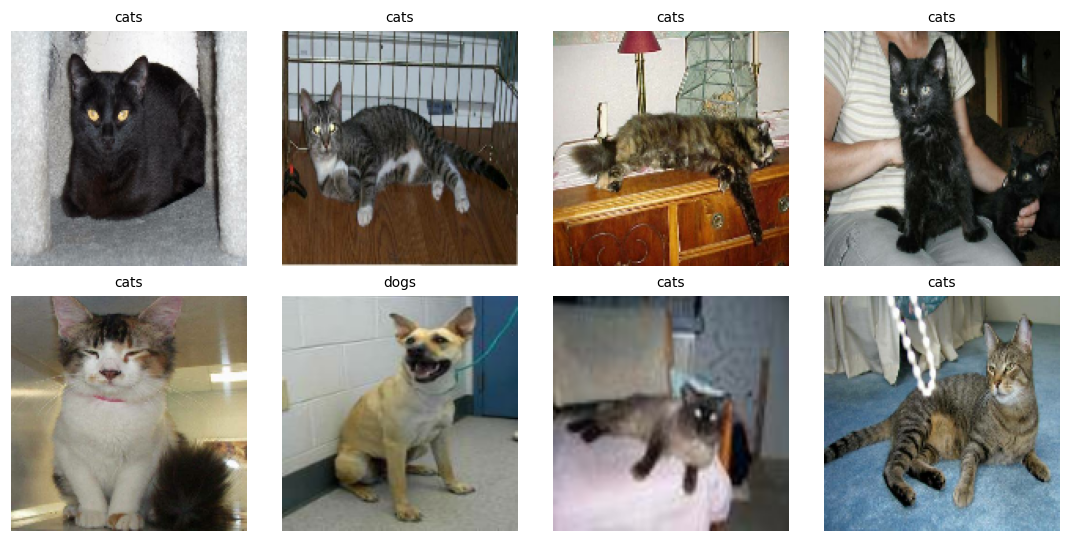

In [5]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i][0])], fontsize=9)
        plt.axis("off")
plt.tight_layout(); plt.show()

The images are highly heterogeneous: varying poses, viewpoints, backgrounds, lighting and sometimes several animals or a human in the frame. This is harder than a
benchmark such as MNIST, where the object is centred, isolated and normalised. Sothe network has to learn
general shapes and not fixed pixel patterns.

---
## Part 3 — Build the CNN Model

### 3.1 — Architecture

So we stack four convolutional blocks, each made of a `Conv2D` layer with ReLU activation followed by a `MaxPooling2D` layer, then a dense head. The number of filters doubles (32 → 64 → 128 → 128) while the spatial resolution is halved by each pooling layer: the representation loses resolution and gains
semantic depth.

In [6]:
def build_baseline():
    return models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Rescaling(1./255),                     # [0,255] -> [0,1]

        layers.Conv2D(32,  3, activation="relu"), layers.MaxPooling2D(2),   # block 1
        layers.Conv2D(64,  3, activation="relu"), layers.MaxPooling2D(2),   # block 2
        layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),   # block 3
        layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),   # block 4

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),        # probability of class "dog"
    ], name="CNN_baseline")

model_A = build_baseline()
model_A.summary()

Model: "CNN_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,905 (3.98 MB)

 Trainable params: 1,043,905 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 — Compile the model: optimizer and loss function

**Loss: `binary_crossentropy`.** We only have two classes, cat or dog, and the model gives one
number between 0 and 1. This loss is the one made for that case: the further the prediction is
from the right answer, the bigger the penalty.

**Optimizer: Adam, learning rate 0.001.** It adapts the step size by
itself while training, so it learns faster than basic gradient descent and we don't have to tune the learning rate.

In [7]:
model_A.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                loss="binary_crossentropy",
                metrics=["accuracy"])

### 3.3 — How many parameters does the model have in total?

For a convolutional layer with $M$ filters of size $K \times K$ over $C_{in}$ input channels, the number of
parameters is $M(K \times K \times C_{in} + 1)$.
A dense layer has $n_{in} \times n_{out} + n_{out}$ parameters.

| Layer | Output shape | Computation | Parameters |
|---|---|---|---|
| `Rescaling` | 150 × 150 × 3 | — | 0 |
| `Conv2D` 32 filters | 148 × 148 × 32 | $32 \times (3 \times 3 \times 3 + 1) = 32 \times 28$ | 896 |
| `MaxPooling2D` | 74 × 74 × 32 | — | 0 |
| `Conv2D` 64 filters | 72 × 72 × 64 | $64 \times (3 \times 3 \times 32 + 1) = 64 \times 289$ | 18,496 |
| `MaxPooling2D` | 36 × 36 × 64 | — | 0 |
| `Conv2D` 128 filters | 34 × 34 × 128 | $128 \times (3 \times 3 \times 64 + 1) = 128 \times 577$ | 73,856 |
| `MaxPooling2D` | 17 × 17 × 128 | — | 0 |
| `Conv2D` 128 filters | 15 × 15 × 128 | $128 \times (3 \times 3 \times 128 + 1) = 128 \times 1153$ | 147,584 |
| `MaxPooling2D` | 7 × 7 × 128 | — | 0 |
| `Flatten` | 6,272 | $7 \times 7 \times 128$ | 0 |
| `Dense` 128 | 128 | $6272 \times 128 + 128$ | 802,944 |
| `Dense` 1 | 1 | $128 \times 1 + 1$ | 129 |
| | | **Total** | **1,043,905** |

In [8]:
conv  = [32*(3*3*3+1), 64*(3*3*32+1), 128*(3*3*64+1), 128*(3*3*128+1)]
dense = [6272*128+128, 128*1+1]

print("Convolutional layers:", conv, "-> ", sum(conv))
print("Dense layers        :", dense, "-> ", sum(dense))
print("Total computed by hand:", sum(conv) + sum(dense))
print("Total reported by Keras:", model_A.count_params())
print("Share held by the dense head: {:.1%}".format(sum(dense) / (sum(conv) + sum(dense))))

Convolutional layers: [896, 18496, 73856, 147584] ->  240832
Dense layers        : [802944, 129] ->  803073
Total computed by hand: 1043905
Total reported by Keras: 1043905
Share held by the dense head: 76.9%


The model has **1,043,905 parameters.** The mathematical calculation is the same as the `model.summary()` result.

---
## Part 4 — Train the Model

### 4.1 — Training

The model is trained for 15 epochs with batches of 100 images. With 1,600 training images
this gives $1600 / 100 = 16$ batches per epoch, so $16 \times 15 = 240$ weight updates in total.

In [9]:
history_A = model_A.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

Epoch 1/15


16/16 - 25s - 2s/step - accuracy: 0.4925 - loss: 0.6945 - val_accuracy: 0.5140 - val_loss: 0.6883


Epoch 2/15


16/16 - 34s - 2s/step - accuracy: 0.5544 - loss: 0.6847 - val_accuracy: 0.5780 - val_loss: 0.6674


Epoch 3/15


...

16/16 - 15s - 960ms/step - accuracy: 0.8263 - loss: 0.3654 - val_accuracy: 0.7420 - val_loss: 0.5849


Epoch 14/15


16/16 - 15s - 934ms/step - accuracy: 0.8656 - loss: 0.3025 - val_accuracy: 0.7260 - val_loss: 0.6814


Epoch 15/15


16/16 - 15s - 949ms/step - accuracy: 0.8750 - loss: 0.2940 - val_accuracy: 0.6960 - val_loss: 0.7427


### 4.2 — Track training and validation accuracy / loss over time

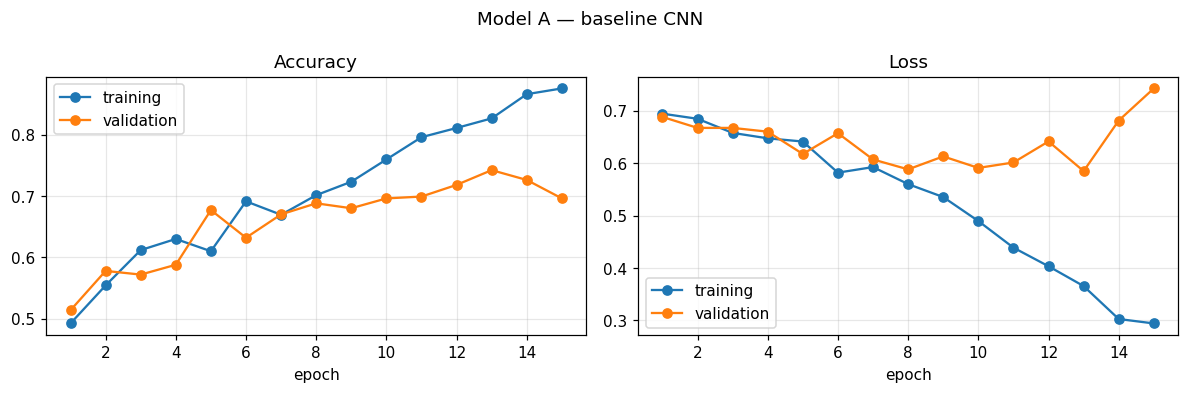

Final training accuracy   : 0.875
Final validation accuracy : 0.696
Generalisation gap        : 0.179
Validation loss: min 0.585 at epoch 13, final 0.743


In [10]:
def plot_history(history, title):
    h = history.history
    ep = range(1, len(h["accuracy"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].plot(ep, h["accuracy"], "o-", label="training")
    ax[0].plot(ep, h["val_accuracy"], "o-", label="validation")
    ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep, h["loss"], "o-", label="training")
    ax[1].plot(ep, h["val_loss"], "o-", label="validation")
    ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.suptitle(title); plt.tight_layout(); plt.show()

    print(f"Final training accuracy   : {h['accuracy'][-1]:.3f}")
    print(f"Final validation accuracy : {h['val_accuracy'][-1]:.3f}")
    print(f"Generalisation gap        : {h['accuracy'][-1] - h['val_accuracy'][-1]:.3f}")
    print(f"Validation loss: min {min(h['val_loss']):.3f} at epoch {np.argmin(h['val_loss']) + 1}"
          f", final {h['val_loss'][-1]:.3f}")

plot_history(history_A, "Model A — baseline CNN")

### 4.3 — Does the model overfit or underfit?

**The model overfits.** It ends at 0.875 accuracy on the training images and yet only 0.696 on the validation images.

The training curve keeps going up until the last epoch, while the
validation curve stops improving around epoch 8. The loss shows it better: the training loss
keeps going down, but the validation loss stops falling in the middle of training and starts going
back up. So the model keeps improving on the images it has already seen, and worse on the
new ones. So it is probably just learning them by heart.

It is not underfitting: because otherwise both curves would stay low and close together, which would mean
the model is too simple for the task. Here the training curve goes high.

We only have 1,600 training images, which is very little for photos that are so different, like said before they are not pictures of just clear cats and dogs, there are also persons on the pictures or from a certai angle. On top of that the model has more than a million parameters, so more than it needs to just memorise them.
We should probably add dropouts or more data for it to be more precise and efficient.

---
## Part 5 — Evaluate the Model on the Test Set


### 5.1 & 5.2 — Confusion matrix, accuracy, precision, recall and F1-score

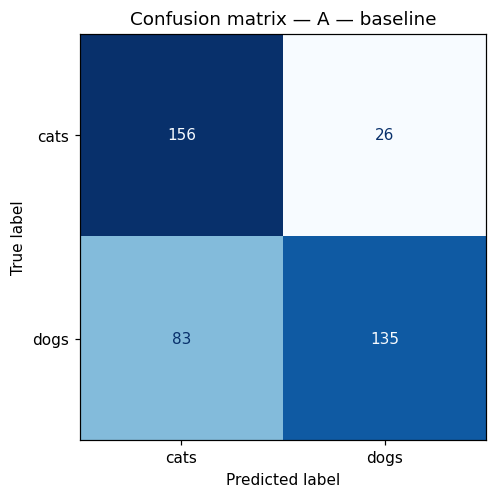

              precision    recall  f1-score   support

        cats       0.65      0.86      0.74       182
        dogs       0.84      0.62      0.71       218

    accuracy                           0.73       400
   macro avg       0.75      0.74      0.73       400
weighted avg       0.75      0.73      0.73       400



In [11]:
def evaluate(model, name):
    """Predict on the test set and report the confusion matrix and the four metrics."""
    proba  = model.predict(X_test, verbose=0).ravel()
    y_pred = (proba > 0.5).astype(int)          # decision threshold at 0.5

    scores = {"model": name,
              "accuracy":  accuracy_score(y_test, y_pred),
              "precision": precision_score(y_test, y_pred, zero_division=0),
              "recall":    recall_score(y_test, y_pred, zero_division=0),
              "f1":        f1_score(y_test, y_pred, zero_division=0)}

    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=class_names).plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion matrix — {name}"); plt.show()

    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    return scores

scores_A = evaluate(model_A, "A — baseline")

### 5.2 — What can we say about the model?

The model performs clearly above the 0.50 baseline, so it has learned the visual differneces and not just learned by heart.
It however misclassifies a good share of the test images,
which is logical because like we said before there is definitly overfitting.


The four metrics also show that the precision is 0.839 but recall
is only 0.619.
So when the model says "dog" it is usually right, but it misses almost four dogs out of ten ( 40%° ). It is too careful with the dog class and answers "cat" whenever it hesitates or doesn't know.



---
## Part 6 — Improving the Model


### 6.1 — Data augmentation

Random transformations (horizontal flip, rotation, zoom) are applied to the training images.

`RandomFlip`, `RandomRotation` and `RandomZoom` are **active during
`fit()` and inactive during `predict()` and `evaluate()`**.

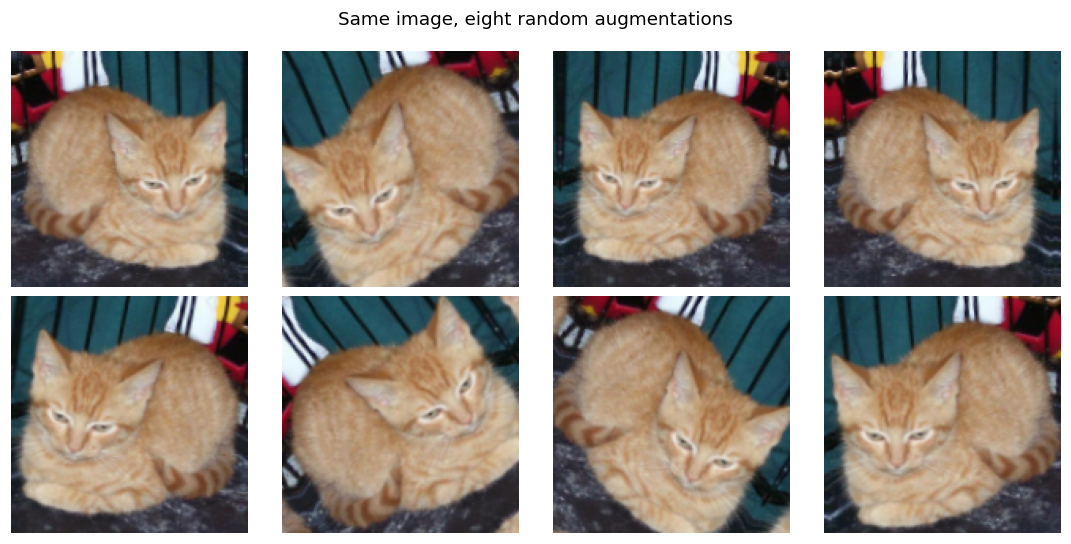

In [12]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

# Eight augmented versions of a single training image
for images, _ in train_ds.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(8):
        aug = augmentation(tf.expand_dims(images[0], 0), training=True)
        plt.subplot(2, 4, i + 1); plt.imshow(aug[0].numpy().astype("uint8")); plt.axis("off")
    plt.suptitle("Same image, eight random augmentations"); plt.tight_layout(); plt.show()

In [13]:
model_B = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    augmentation,                                 # only difference with model A
    layers.Rescaling(1./255),
    layers.Conv2D(32,  3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64,  3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="CNN_augmented")

model_B.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="binary_crossentropy", metrics=["accuracy"])

history_B = model_B.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

Epoch 1/15


16/16 - 20s - 1s/step - accuracy: 0.5006 - loss: 0.7067 - val_accuracy: 0.5000 - val_loss: 0.6903


Epoch 2/15


16/16 - 18s - 1s/step - accuracy: 0.5169 - loss: 0.6930 - val_accuracy: 0.5760 - val_loss: 0.6834


Epoch 3/15


...

16/16 - 20s - 1s/step - accuracy: 0.6637 - loss: 0.6186 - val_accuracy: 0.6560 - val_loss: 0.6099


Epoch 14/15


16/16 - 17s - 1s/step - accuracy: 0.6856 - loss: 0.5977 - val_accuracy: 0.6850 - val_loss: 0.5765


Epoch 15/15


16/16 - 17s - 1s/step - accuracy: 0.6925 - loss: 0.5881 - val_accuracy: 0.6830 - val_loss: 0.5804


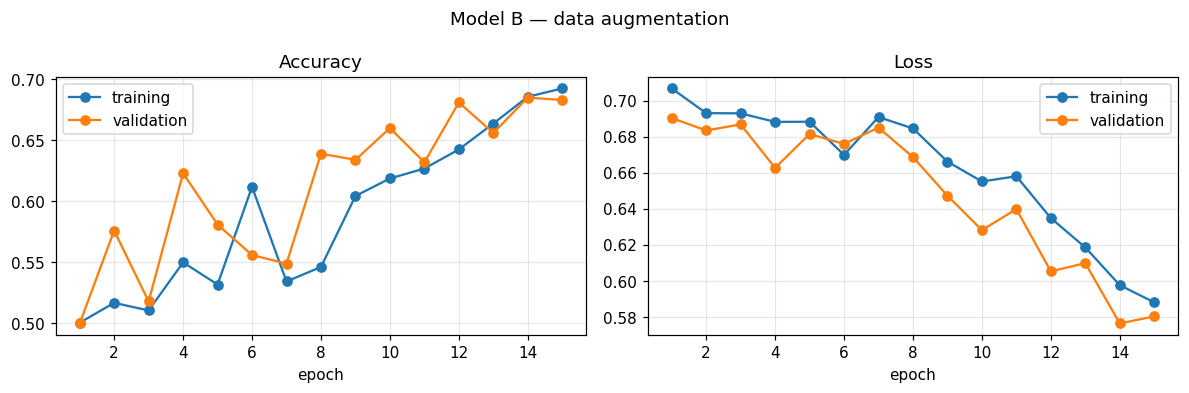

Final training accuracy   : 0.692
Final validation accuracy : 0.683
Generalisation gap        : 0.009
Validation loss: min 0.576 at epoch 14, final 0.580


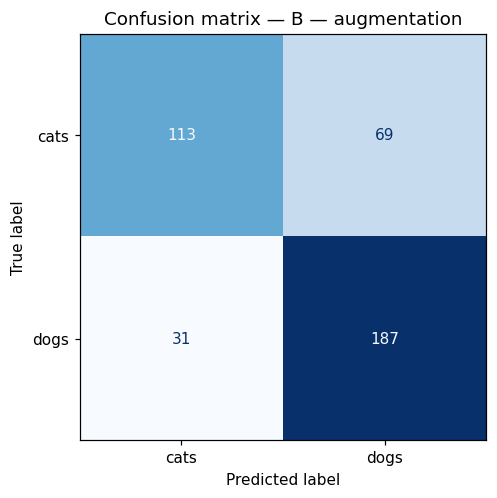

              precision    recall  f1-score   support

        cats       0.78      0.62      0.69       182
        dogs       0.73      0.86      0.79       218

    accuracy                           0.75       400
   macro avg       0.76      0.74      0.74       400
weighted avg       0.76      0.75      0.75       400



In [14]:
plot_history(history_B, "Model B — data augmentation")
scores_B = evaluate(model_B, "B — augmentation")

The two curves are now almost on top of each other: the difference between training and validation accuracy drops down from 0.179 to 0.009, and the validation loss stops going up.

The training accuracy is lower than model A's (0.692 against 0.875), wich indicates that the images are different at every epoch,so the model can no longer just remember the images. On the test set, we can see that the accuracy goes up to 0.750 and recall goes from 0.619 to 0.858. This means the model doesn't juste gives us ' cat ' back when he doesn't know.

### 6.2 — Dropout and batch normalization

In [15]:
def conv_block(filters):
    """Conv -> BatchNorm -> ReLU -> MaxPool."""
    return [layers.Conv2D(filters, 3),
            layers.BatchNormalization(momentum=0.9),   # see the note below on the momentum value
            layers.Activation("relu"),
            layers.MaxPooling2D(2)]

model_C = models.Sequential(
    [layers.Input(shape=IMG_SIZE + (3,)), layers.Rescaling(1./255)]
    + conv_block(32) + conv_block(64) + conv_block(128) + conv_block(128)
    + [layers.Flatten(),
       layers.Dense(128, activation="relu"),
       layers.Dropout(0.5),
       layers.Dense(1, activation="sigmoid")],
    name="CNN_dropout_batchnorm")

model_C.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="binary_crossentropy", metrics=["accuracy"])

history_C = model_C.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

Epoch 1/15


16/16 - 36s - 2s/step - accuracy: 0.5350 - loss: 1.3363 - val_accuracy: 0.5000 - val_loss: 0.7194


Epoch 2/15


16/16 - 30s - 2s/step - accuracy: 0.5656 - loss: 0.6780 - val_accuracy: 0.5000 - val_loss: 0.7088


Epoch 3/15


...

16/16 - 32s - 2s/step - accuracy: 0.8250 - loss: 0.3771 - val_accuracy: 0.7640 - val_loss: 0.4854


Epoch 14/15


16/16 - 30s - 2s/step - accuracy: 0.8388 - loss: 0.3406 - val_accuracy: 0.7300 - val_loss: 0.5488


Epoch 15/15


16/16 - 44s - 3s/step - accuracy: 0.8681 - loss: 0.2906 - val_accuracy: 0.7830 - val_loss: 0.5063


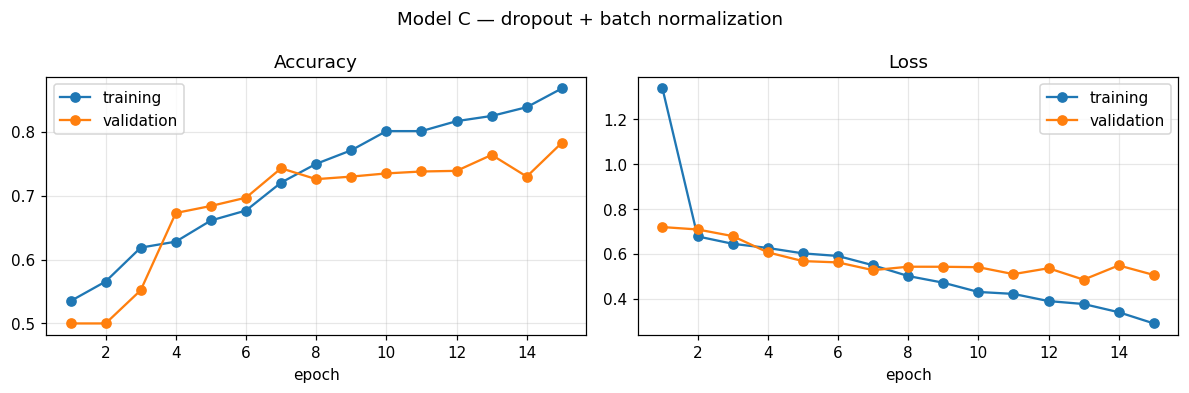

Final training accuracy   : 0.868
Final validation accuracy : 0.783
Generalisation gap        : 0.085
Validation loss: min 0.485 at epoch 13, final 0.506


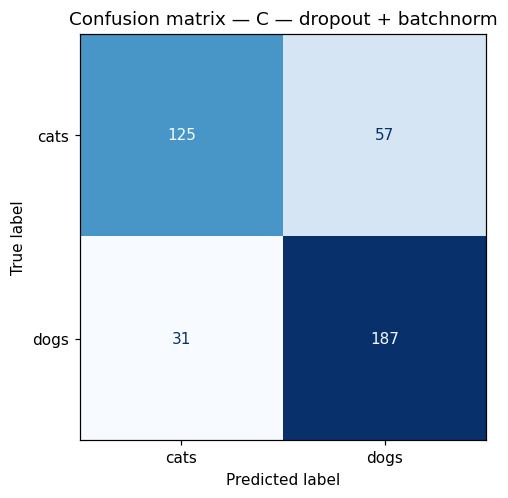

              precision    recall  f1-score   support

        cats       0.80      0.69      0.74       182
        dogs       0.77      0.86      0.81       218

    accuracy                           0.78       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400



In [16]:
plot_history(history_C, "Model C — dropout + batch normalization")
scores_C = evaluate(model_C, "C — dropout + batchnorm")

As we can see this is the best of the three models on the test set. Batch normalization lets the model reach
a higher training accuracy as fast as the baseline and still keeping a higher validation accuracy.


### 6.3 — Comparison of the three models

In [17]:
def gap(history):
    h = history.history
    return h["accuracy"][-1] - h["val_accuracy"][-1]

results = pd.DataFrame([scores_A, scores_B, scores_C]).set_index("model")
results["train/val gap"] = [gap(history_A), gap(history_B), gap(history_C)]
results = results.round(3)
results

,accuracy,precision,recall,f1,train/val gap
model,,,,,
A — baseline,0.728,0.839,0.619,0.712,0.179
B — augmentation,0.750,0.730,0.858,0.789,0.009
C — dropout + batchnorm,0.780,0.766,0.858,0.810,0.085


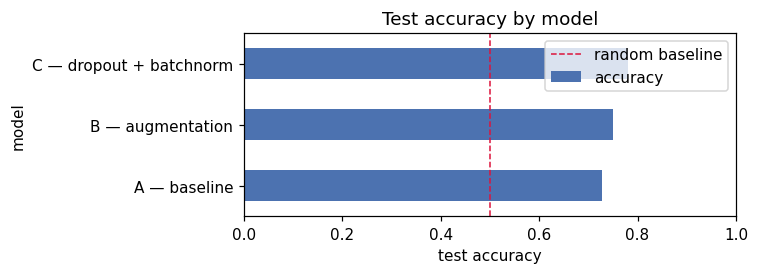

In [18]:
ax = results["accuracy"].plot(kind="barh", figsize=(7, 2.6), color="#4C72B0")
ax.axvline(0.5, color="crimson", ls="--", lw=1, label="random baseline")
ax.set_xlim(0, 1); ax.set_xlabel("test accuracy"); ax.legend()
plt.title("Test accuracy by model"); plt.tight_layout(); plt.show()

---
## Conclusion

| Model | Test accuracy | F1-score | Train/val gap |
|---|---|---|---|
| A — baseline CNN | 0.728 | 0.712 | 0.179 |
| B — data augmentation | 0.750 | 0.789 | **0.009** |
| C — dropout + batch normalization | **0.780** | **0.810** | 0.085 |


- The baseline CNN works: it has 1,043,905 parameters and does learn real visual features. But it
  memorises its 1,600 training images well before the fifteenth epoch.
- The limit is the amount of data, not the architecture. Both fixes improved the results without
  adding a convolutional filter.
- The two fixes do not work the same way. Augmentation almost removes the gap between the two curves,
  while dropout and batch normalization reach the best final score.

**What we could do next.** Combine augmentation with dropout and batch normalization in one model;
add `EarlyStopping` on the validation loss; train on the full 25,000-image Kaggle dataset instead of
this 3,000-image subset. With only 1,600 images, using a model pre-trained on a large dataset would most probably be the most effective next step.